In [14]:
import numpy as np
import pandas as py
import matplotlib.pyplot as plt

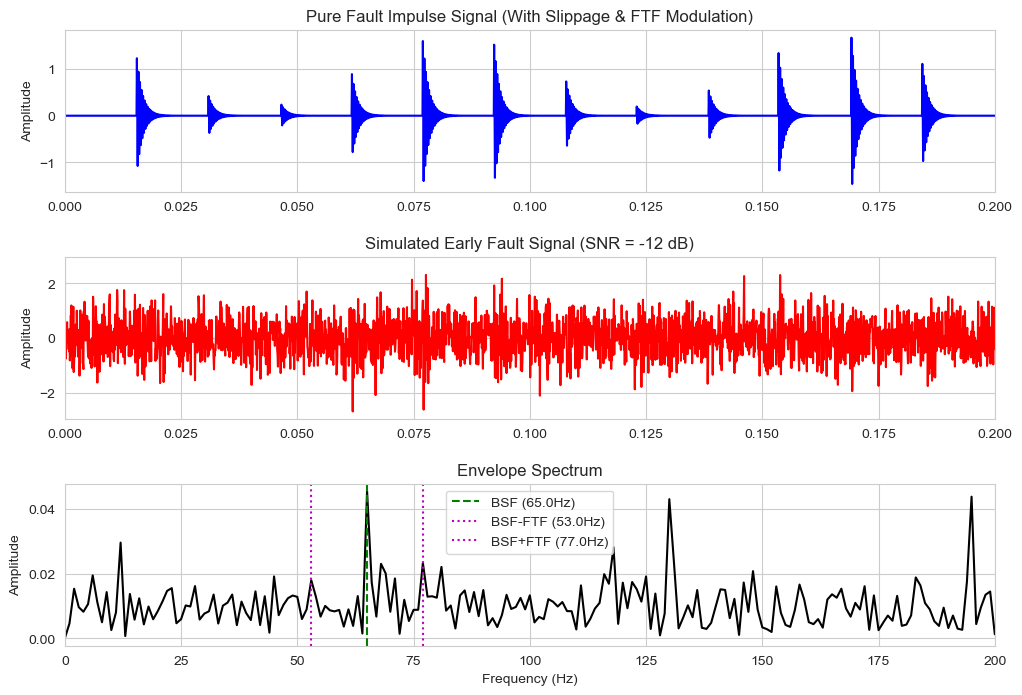

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def simulate_rolling_element_fault(fs=12000, duration=1.0, snr_db=-10):
    """
    模拟滚动体初期故障振动信号
    
    参数:
    fs: 采样频率 (Hz)
    duration: 信号时长 (s)
    snr_db: 信噪比 (dB)，初期故障通常在 -10 到 -15 dB
    """
    t = np.arange(0, duration, 1/fs)
    N = len(t)
    
    # --- 1. 定义轴承特征频率先验参数 ---
    bsf = 65.0      # 滚动体自转频率 (Ball Spin Frequency), 假设为 65 Hz
    ftf = 12.0      # 保持架公转频率 (Fundamental Train Frequency), 假设为 12 Hz
    fn = 3000.0     # 轴承系统的高频固有共振频率 (Hz)
    beta = 800.0    # 结构阻尼系数 (决定冲击衰减快慢)
    
    # 滚动体缺陷通常每次自转撞击内外圈各一次，冲击频率为 2*BSF
    # 这里我们简化为单侧撞击或以 BSF 为主要特征周期来模拟
    fault_freq = bsf 
    T = 1.0 / fault_freq
    
    # --- 2. 生成带随机打滑的冲击序列 ---
    num_impacts = int(np.floor(duration / T))
    signal_clean = np.zeros(N)
    
    # 模拟打滑带来的周期误差 (标准差为周期的 1.5%)
    slip_std = 0.015 * T 
    
    for i in range(num_impacts):
        # 加入随机打滑时间偏移
        tau_i = np.random.normal(0, slip_std)
        t_impact = i * T + tau_i
        
        if t_impact < 0 or t_impact >= duration:
            continue
            
        # 截取从当前冲击点开始的时间向量
        idx_start = int(t_impact * fs)
        t_decay = t[idx_start:] - t[idx_start]
        
        # --- 3. 保持架转频幅值调制 (进出承载区) ---
        # 冲击幅值受保持架频率 ftf 调制
        A_i = 1.0 + 0.8 * np.cos(2 * np.pi * ftf * t_impact)
        
        # --- 4. 生成单次指数衰减振铃响应 ---
        response = A_i * np.exp(-beta * t_decay) * np.sin(2 * np.pi * fn * t_decay)
        
        # 叠加到总信号中
        signal_clean[idx_start:] += response

    # --- 5. 加入极强的背景噪声模拟初期故障 ---
    # 计算纯净信号功率
    power_signal = np.sum(signal_clean**2) / N
    # 根据目标 SNR 计算噪声功率
    power_noise = power_signal / (10 ** (snr_db / 10))
    # 生成高斯白噪声
    noise = np.random.normal(0, np.sqrt(power_noise), N)
    
    signal_noisy = signal_clean + noise
    return t, signal_noisy, signal_clean

# ================= 运行仿真与可视化 =================
fs = 12000
t, sig_noisy, sig_clean = simulate_rolling_element_fault(fs=fs, duration=1.0, snr_db=-12)

# 计算包络谱 (Envelope Spectrum) 验证理论特征
analytic_signal = hilbert(sig_noisy)
amplitude_envelope = np.abs(analytic_signal)
# 去直流分量
amplitude_envelope -= np.mean(amplitude_envelope)
# FFT
N = len(amplitude_envelope)
frequencies = np.fft.fftfreq(N, 1/fs)[:N//2]
envelope_spectrum = np.abs(np.fft.fft(amplitude_envelope))[:N//2] / N * 2

# 绘图
plt.figure(figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

plt.subplot(3, 1, 1)
plt.plot(t, sig_clean, color='b')
plt.title('Pure Fault Impulse Signal (With Slippage & FTF Modulation)')
plt.ylabel('Amplitude')
plt.xlim(0, 0.2) # 只看前 0.2 秒细节

plt.subplot(3, 1, 2)
plt.plot(t, sig_noisy, color='r')
plt.title('Simulated Early Fault Signal (SNR = -12 dB)')
plt.ylabel('Amplitude')
plt.xlim(0, 0.2)

plt.subplot(3, 1, 3)
plt.plot(frequencies, envelope_spectrum, color='k')
plt.title('Envelope Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 200)

# 标记理论频率
bsf, ftf = 65.0, 12.0
plt.axvline(x=bsf, color='g', linestyle='--', label=f'BSF ({bsf}Hz)')
plt.axvline(x=bsf-ftf, color='m', linestyle=':', label=f'BSF-FTF ({bsf-ftf}Hz)')
plt.axvline(x=bsf+ftf, color='m', linestyle=':', label=f'BSF+FTF ({bsf+ftf}Hz)')
plt.legend()
plt.grid(True)
plt.show()

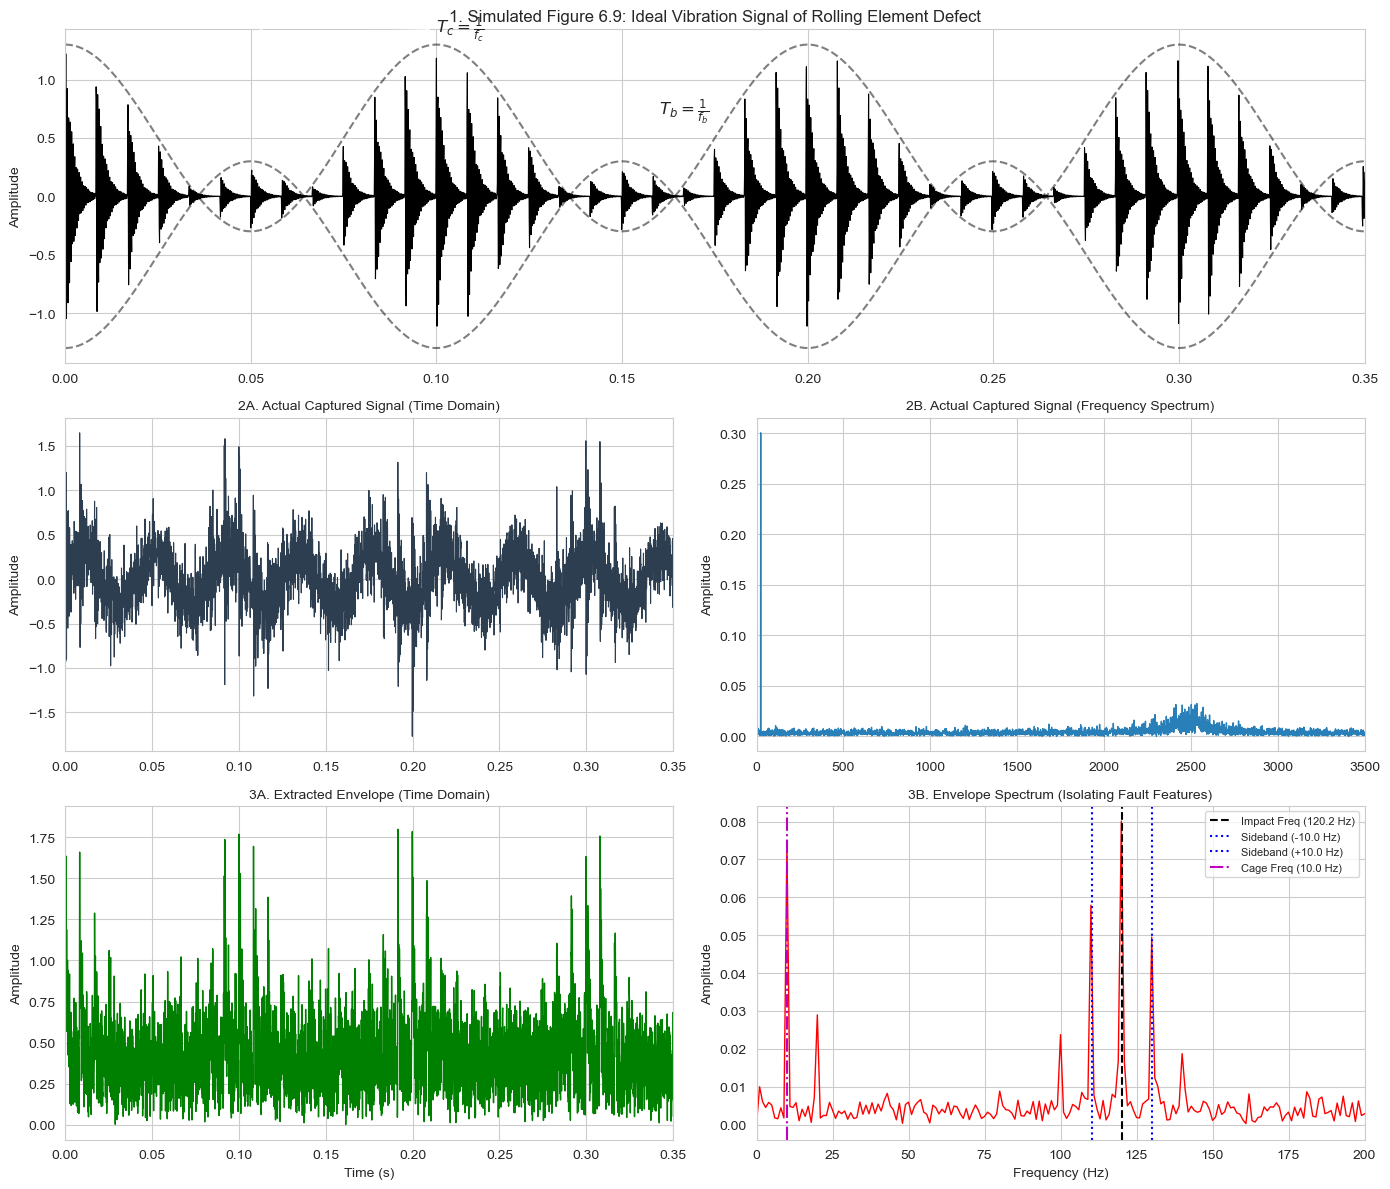

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# ==========================================
# 1. 采用书本【表 6.1】的真实轴承参数
# ==========================================
fs = 12000          # 采样频率 (Hz)
duration = 1.0      # 信号时长 (秒)
N = int(fs * duration)
t = np.arange(0, duration, 1/fs)

f_r = 24.0          # 转轴基频 (1440 r/min -> 24 Hz)
f_c = 10.0          # 保持架公转频率 (Hz) -> 决定大周期 Tc
f_bsf = 60.1        # 滚柱自转频率 (Hz)
f_fault = f_bsf * 2 # 滚动体故障冲击频率 (120.2 Hz) -> 决定小周期 Tb
f_n = 2500          # 系统高频共振频率 (Hz，模拟图6.9的密集波形)
damping = 500       # 衰减系数

# ==========================================
# 2. 依据书中描述合成信号
# ==========================================
signal_fault = np.zeros(N)
T_fault = 1.0 / f_fault  # 冲击间隔 Tb
T_cage = 1.0 / f_c       # 调制周期 Tc

for tau in np.arange(0, duration, T_fault):
    # 模拟实际存在的微小打滑滑动
    slip = np.random.normal(0, 0.01 * T_fault) 
    tau_actual = tau + slip
    if tau_actual >= duration or tau_actual < 0: continue
    
    # 【核心】书中描述的“脉冲幅值出现周期性变化”，周期为公转频率 fc
    # 这里加了一个基底0.2，防止非承载区冲击为0，更符合物理实际
    A_mod = 0.5 + 0.8 * np.cos(2 * np.pi * f_c * tau_actual) 
    
    idx = t >= tau_actual
    time_decay = t[idx] - tau_actual
    # 瞬态高频衰减共振
    signal_fault[idx] += A_mod * np.exp(-damping * time_decay) * np.sin(2 * np.pi * f_n * time_decay)

# 加入少量环境噪声和转轴低频干扰，使综合信号更真实
noise = np.random.normal(0, 0.2, N)
signal_macro = 0.3 * np.sin(2 * np.pi * f_r * t)
signal_combined = signal_fault + signal_macro + noise

# 计算合成信号的包络及包络谱
analytic_signal = hilbert(signal_combined)
signal_envelope = np.abs(analytic_signal)
signal_envelope_detrend = signal_envelope - np.mean(signal_envelope)

def get_fft(signal, fs):
    N = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal)) * 2 / N
    freqs = np.fft.rfftfreq(N, 1/fs)
    return freqs, fft_vals

freqs_comb, fft_comb = get_fft(signal_combined, fs)
freqs_env, fft_env = get_fft(signal_envelope_detrend, fs)

# ==========================================
# 3. 可视化绘制
# ==========================================
fig = plt.figure(figsize=(14, 12))

# --- 图 1：高仿书中图 6.9 的纯净示意图 ---
ax1 = plt.subplot(3, 1, 1)
ax1.plot(t, signal_fault, 'k', linewidth=0.8) # 用黑色线条模仿书本印刷
# 叠加包络虚线
ax1.plot(t, 0.5 + 0.8 * np.cos(2 * np.pi * f_c * t), 'k--', alpha=0.5)
ax1.plot(t, -(0.5 + 0.8 * np.cos(2 * np.pi * f_c * t)), 'k--', alpha=0.5)
ax1.set_xlim(0, 0.35) # 展示大约3个调制周期
ax1.set_title("1. Simulated Figure 6.9: Ideal Vibration Signal of Rolling Element Defect", fontsize=12)
ax1.set_ylabel("Amplitude")
# 添加类似书中的周期标注
ax1.annotate(r'$T_c = \frac{1}{f_c}$', xy=(0.05, 1.4), xytext=(0.1, 1.4), arrowprops=dict(arrowstyle='<->'), fontsize=12)
ax1.annotate(r'$T_b = \frac{1}{f_b}$', xy=(0.15, 0.5), xytext=(0.16, 0.7), arrowprops=dict(arrowstyle='<->'), fontsize=12)

# --- 图 2：加入噪声和转频后的实际混合信号频谱 ---
ax2 = plt.subplot(3, 2, 3)
ax2.plot(t, signal_combined, '#2c3e50', linewidth=0.8)
ax2.set_xlim(0, 0.35)
ax2.set_title("2A. Actual Captured Signal (Time Domain)", fontsize=10)
ax2.set_ylabel("Amplitude")

ax3 = plt.subplot(3, 2, 4)
ax3.plot(freqs_comb, fft_comb, '#2980b9', linewidth=1)
ax3.set_xlim(0, 3500)
ax3.set_title("2B. Actual Captured Signal (Frequency Spectrum)", fontsize=10)
ax3.set_ylabel("Amplitude")

# --- 图 3：包络图与包络谱 (提取书中表 6.1 的特征频率) ---
ax4 = plt.subplot(3, 2, 5)
ax4.plot(t, signal_envelope, 'g', linewidth=1)
ax4.set_xlim(0, 0.35)
ax4.set_title("3A. Extracted Envelope (Time Domain)", fontsize=10)
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Amplitude")

ax5 = plt.subplot(3, 2, 6)
ax5.plot(freqs_env, fft_env, 'r', linewidth=1)
ax5.set_xlim(0, 200)
ax5.set_title("3B. Envelope Spectrum (Isolating Fault Features)", fontsize=10)
ax5.set_xlabel("Frequency (Hz)")
ax5.set_ylabel("Amplitude")

# 标注表 6.1 中的特征频率
ax5.axvline(f_fault, color='k', linestyle='--', label=f'Impact Freq ({f_fault} Hz)')
ax5.axvline(f_fault - f_c, color='b', linestyle=':', label=f'Sideband (-{f_c} Hz)')
ax5.axvline(f_fault + f_c, color='b', linestyle=':', label=f'Sideband (+{f_c} Hz)')
ax5.axvline(f_c, color='m', linestyle='-.', label=f'Cage Freq ({f_c} Hz)')
ax5.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()